# BacheMap — Detección, priorización y georreferenciación de daños viales

Proyecto final de Kevin Galeano y Werner Uibrig para el Diplomado en Machine Learning y Deep Learning Aplicado, FIUNA 2026.

Asunción no tiene un catastro actualizado de daños viales: la inspección es manual y reactiva, se sale a reparar cuando entra un reclamo, así que los baches se atienden tarde, cuando ya crecieron y cuesta más repararlos. La idea de este proyecto es armar algo que le sirva a la Dirección de Vialidad de la Municipalidad para saber dónde están los daños y con cuáles empezar.

El enfoque tiene dos etapas. Primero un detector YOLOv8n que encuentra y clasifica los daños en una foto de calle (cuatro clases: grieta longitudinal, grieta transversal, piel de cocodrilo y bache). Después cada detección pasa por un `Pipeline` de scikit-learn que le asigna una prioridad de reparación, y las detecciones urgentes se agrupan con DBSCAN en focos geográficos, para que una cuadrilla pueda salir a cubrir una zona en vez de ir reclamo por reclamo.

Los datos son de RDD2022 (Arya et al., 2022; CC BY-SA 4.0): fotos de calles de seis países con las cajas ya etiquetadas.

La métrica que más importa acá es el recall, no la accuracy: un bache que el sistema no detecta sigue rompiendo autos, mientras que una falsa alarma sólo hace que un inspector mire una foto de más. Por eso el umbral de confianza se elige maximizando F2 (pondera el recall el doble que la precisión), y se reportan también precisión, F1 y mAP50.

Para no engañarnos con los números, todo lo que hubo que decidir (con qué pesos arranca el detector, el umbral, qué modelo de prioridad usar) lo decidimos mirando sólo validación, y quedó anotado en `selection.json`. El test se abre una sola vez, al final.

Para correrlo hace falta una GPU NVIDIA. Con `uv sync` se arma el entorno, se copia `.env.example` a `.env` con las credenciales de Kaggle (para bajar el dataset `aliabdelmenam/rdd-2022`, ~12 GB, se cachea después de la primera vez) y se ejecuta de arriba a abajo. Todo lo que se genera queda en `bachemap_work/`, y al final se copian a esta carpeta los dos archivos de la entrega (`model.pkl` y `datos_muestra.csv`).


## 0. Configuración
Lo que se puede llegar a cambiar entre una corrida y otra (tamaño de imagen, batch, épocas) quedó acá arriba. Lo demás está en cada sección, donde se usa.

In [1]:
import os, sys, json, time, random, shutil, platform, warnings
from pathlib import Path
from dotenv import load_dotenv

os.environ["YOLO_VERBOSE"] = "False"   # sin barras de progreso de Ultralytics
warnings.filterwarnings("ignore")
load_dotenv()   # credenciales en .env

MODO_PRUEBA = os.environ.get("BACHEMAP_PRUEBA", "0") == "1"   # corrida chica para probar el código

DATASET_KAGGLE = "aliabdelmenam/rdd-2022"   # mirror de RDD2022 en formato YOLO
INPUT_DIR = os.environ.get("BACHEMAP_INPUT")   # si ya está descargado, saltea la descarga
WORK_DIR = Path(os.environ.get("BACHEMAP_WORK", "./bachemap_work")).resolve()
SEED = 42

CLASES = ["D00", "D10", "D20", "D40"]
NOMBRES_ES = {"D00": "Grieta longitudinal", "D10": "Grieta transversal",
              "D20": "Piel de cocodrilo", "D40": "Bache"}
MAX_IMAGENES = None   # p. ej. 15000 para una corrida más corta

MODELO_BASE = "yolov8n.pt"   # pesa 6 MB, entra en el ZIP
IMGSZ = 640
BATCH = 16          # esta GPU tiene 6 GB de VRAM
WORKERS = min(4, os.cpu_count() or 4)   # con 8 se quedaba sin RAM
EPOCHS = 100
PATIENCE = 30       # épocas sin mejora antes de cortar

COMPARAR_TRANSFER = True
COMP_EPOCHS, COMP_FRACCION = 5, 0.25

if MODO_PRUEBA:
    IMGSZ, BATCH, EPOCHS, PATIENCE = 256, 8, 6, 50
    COMP_EPOCHS, COMP_FRACCION = 2, 1.0

from tqdm import tqdm
t_inicio = time.time()

def paso(msg):   # imprime la hora al empezar cada etapa
    print(f"\n[{time.strftime('%H:%M:%S')}] {msg}", flush=True)

def barra(it, desc, total=None):   # tqdm, refresco cada 5 s
    return tqdm(it, desc=f"   {desc}", total=total, mininterval=5, ncols=100, file=sys.stdout)

FIGS = WORK_DIR / "figs"
FIGS.mkdir(parents=True, exist_ok=True)
(WORK_DIR / "artefactos").mkdir(exist_ok=True)
print("Modo prueba:", MODO_PRUEBA, "| carpeta de trabajo:", WORK_DIR)

Modo prueba: False | carpeta de trabajo: /home/kevin/bachemap/bachemap_work


## 1. Entorno y reproducibilidad

In [2]:
paso("Entorno: importando librerías")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, sklearn, joblib, ultralytics
from PIL import Image
from ultralytics import YOLO

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = 0 if torch.cuda.is_available() else "cpu"

# queda en el bundle y en metadata.json
versiones = {"python": platform.python_version(), "torch": str(torch.__version__),
             "ultralytics": ultralytics.__version__, "scikit-learn": sklearn.__version__,
             "numpy": np.__version__, "pandas": pd.__version__, "joblib": joblib.__version__}
print(versiones)
if device == 0:
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)} ({vram:.1f} GB de VRAM) · CUDA {torch.version.cuda}")
else:
    print("Sin GPU: usar BACHEMAP_PRUEBA=1 para probar el código.")

# una sola corrida de W&B para todo el notebook
run_wandb = None
if os.environ.get("WANDB_API_KEY") and os.environ.get("BACHEMAP_WANDB", "1") == "1":
    import wandb
    from ultralytics import settings
    settings.update({"wandb": True})
    run_wandb = wandb.init(project=os.environ.get("WANDB_PROJECT", "bachemap"),
                           name=f"bachemap-{time.strftime('%Y%m%d-%H%M')}", job_type="entrenamiento",
                           config={"modelo_base": MODELO_BASE, "imgsz": IMGSZ, "batch": BATCH,
                                   "epochs": EPOCHS, "seed": SEED, "dataset": DATASET_KAGGLE})
    print("Corrida de W&B:", run_wandb.url)
else:
    print("Sin W&B: no hay WANDB_API_KEY, o BACHEMAP_WANDB=0.")


[18:31:04] Entorno: importando librerías
{'python': '3.11.16', 'torch': '2.14.0+cu130', 'ultralytics': '8.4.160', 'scikit-learn': '1.9.1', 'numpy': '2.4.6', 'pandas': '3.0.6', 'joblib': '1.6.0'}
GPU: NVIDIA GeForce RTX 4050 Laptop GPU (6.0 GB de VRAM) · CUDA 13.0


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gsmkev (gsmkev-universidad-nacional-de-asunci-n) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Corrida de W&B: https://wandb.ai/gsmkev-universidad-nacional-de-asunci-n/bachemap/runs/45qis8wj


## 2. Carga de datos
El dataset viene en formato YOLO y ya separado en `train/`, `val/` y `test/`. Cada una de esas carpetas tiene `images/` y `labels/`, con un `.txt` por foto y las cajas en coordenadas normalizadas.

Ojo con un detalle: los ids de clase de este mirror no siguen el orden de RDD2022. Acá el 3 es `other_corruption` y el 4 es `pothole`, y como el dataset no trae un `.yaml` con los nombres, el mapeo a D00/D10/D20/D40 está escrito a mano en la celda de abajo. Para confirmar que está bien, en la sección 3 miramos recortes de cada clase.

Al final quedan dos tablas: una con una fila por imagen y otra con una fila por caja.

In [3]:
paso("Dataset: ubicando los datos")
if INPUT_DIR:
    INPUT_DIR = Path(INPUT_DIR).resolve()
else:
    import kagglehub
    # ~12 GB la primera vez, después usa el caché
    print(f"   descargando {DATASET_KAGGLE}...", flush=True)
    INPUT_DIR = Path(kagglehub.dataset_download(DATASET_KAGGLE)).resolve()
print("Dataset en", INPUT_DIR)
print("Contenido:", sorted(p.name for p in INPUT_DIR.iterdir()))


[18:31:22] Dataset: ubicando los datos
   descargando aliabdelmenam/rdd-2022...
Dataset en /home/kevin/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1
Contenido: ['RDD_SPLIT']


In [4]:
import yaml

# mapeo verificado a mano (recortes en sección 3); other_corruption (3) queda afuera
# 0 longitudinal, 1 transversal, 2 cocodrilo, 3 other_corruption, 4 pothole
mapa_ids = {0: "D00", 1: "D10", 2: "D20", 3: None, 4: "D40"}

def cargar_yolo(root):
    imgs, cajas = [], []
    descartes = {"other_corruption": 0, "caja_degenerada": 0}
    lista = sorted(root.rglob("*.jpg"))
    print(f"   {len(lista):,} imágenes encontradas, leyendo etiquetas...", flush=True)
    for img in barra(lista, "leyendo etiquetas"):
        # estructura: <split>/images/<nombre>.jpg y <split>/labels/<nombre>.txt
        carpeta_split = img.parent.parent
        pais = img.stem.rsplit("_", 1)[0]   # prefijo del nombre, ej. Japan_001234
        imgs.append({"img_id": img.stem, "ruta": str(img), "pais": pais, "split": carpeta_split.name})

        etiqueta = carpeta_split / "labels" / (img.stem + ".txt")
        for linea in etiqueta.read_text().splitlines():
            valores = linea.split()
            clase = mapa_ids[int(valores[0])]
            cx, cy, w, h = [float(v) for v in valores[1:5]]
            if clase is None:
                descartes["other_corruption"] += 1
            elif w <= 0.002 or h <= 0.002:   # menos de ~1 px a 640: error de anotación
                descartes["caja_degenerada"] += 1
            else:
                cajas.append({"img_id": img.stem, "clase": clase, "cx": cx, "cy": cy, "w": w, "h": h})
    return pd.DataFrame(imgs), pd.DataFrame(cajas), descartes

paso(f"Carga de datos desde {INPUT_DIR}")
imgs_df, cajas_df, descartes = cargar_yolo(INPUT_DIR)
assert imgs_df["img_id"].is_unique, "hay nombres de imagen repetidos"
assert set(imgs_df["split"]) == {"train", "val", "test"}, "esperaba las carpetas train/val/test"
print(f"Imágenes: {len(imgs_df):,} | cajas: {len(cajas_df):,}")
print("Cajas descartadas al cargar:", descartes)


[18:31:26] Carga de datos desde /home/kevin/.cache/kagglehub/datasets/aliabdelmenam/rdd-2022/versions/1
   38,385 imágenes encontradas, leyendo etiquetas...
   leyendo etiquetas: 100%|████████████████████████████████| 38385/38385 [00:02<00:00, 16823.99it/s]
Imágenes: 38,385 | cajas: 55,005
Cajas descartadas al cargar: {'other_corruption': 10705, 'caja_degenerada': 2}


## 3. Análisis exploratorio
Antes de entrenar queríamos responder tres cosas:
1. Cuántas fotos aporta cada país y cuántas no tienen ningún daño (o sea, cuánto "fondo" hay).
2. Si las clases están balanceadas. No lo están, y los baches son justo la clase más chica; por eso más adelante miramos el recall por clase y no la accuracy.
3. Qué tan chicos son los objetos. Esto tiene que ver con entrenar a `imgsz=640`, y ayuda a entender por qué las grietas finas cuestan tanto.

La última figura es sólo de control: unos recortes de cada clase para comprobar a ojo que el mapeo de ids está bien.


[18:31:35] Análisis exploratorio


,imagenes,cajas,sin_danio,con_bache,%_sin_danio
pais,,,,,
China_Drone,2401,3068,482,64,20.1
China_MotorBike,1977,4650,43,164,2.2
Czech,2829,1745,1757,154,62.1
India,7706,6831,4483,1530,58.2
Japan,10506,16469,2606,1390,24.8
Norway,8161,11228,5247,256,64.3
United_States,4805,11014,0,116,0.0


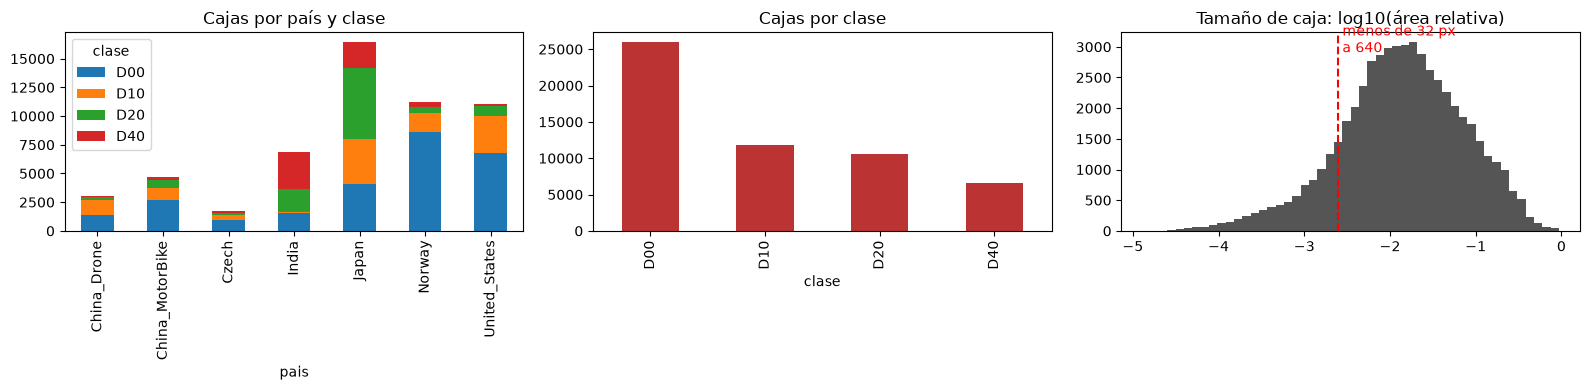

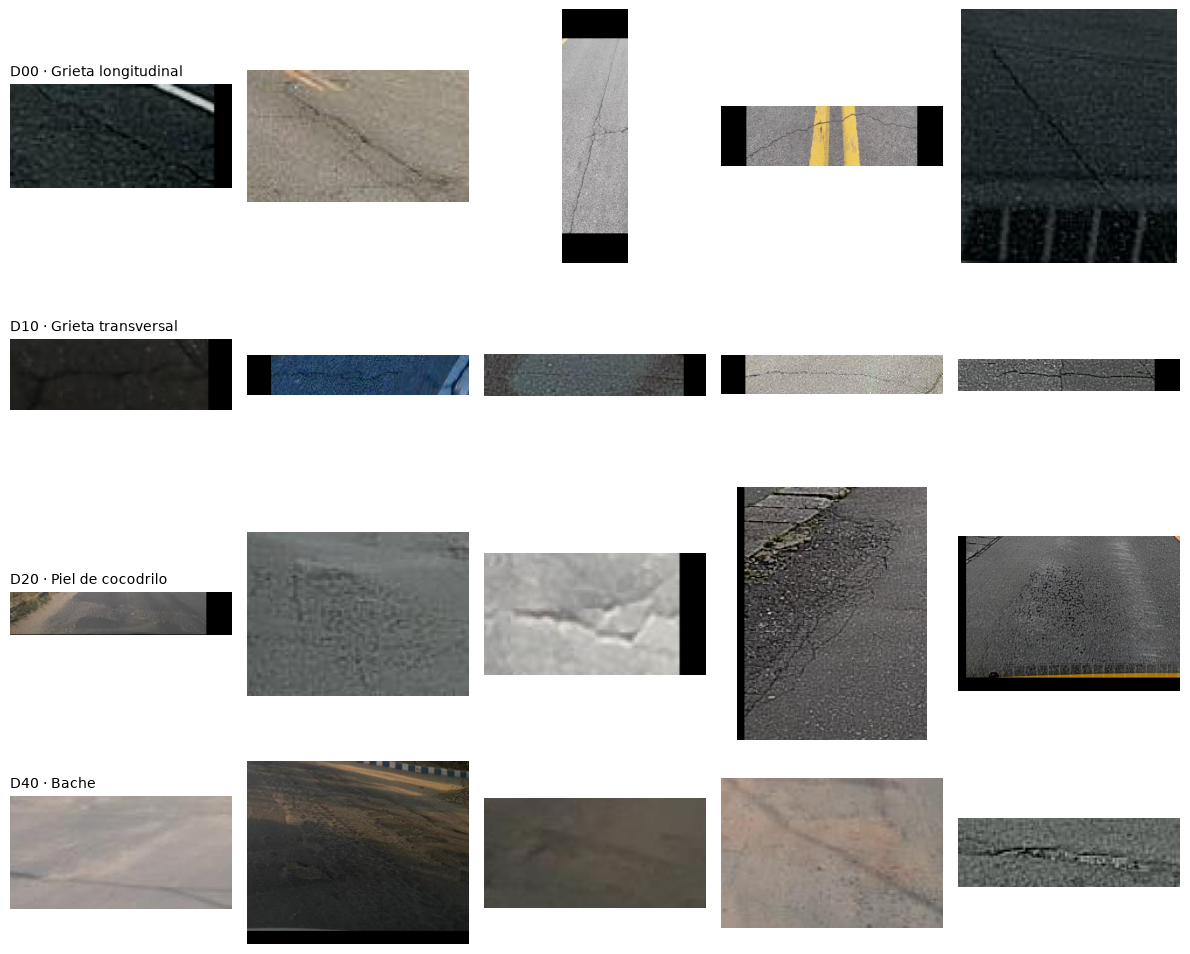

Proporción de clases: {'D00': 0.473, 'D10': 0.215, 'D20': 0.193, 'D40': 0.119}
Cajas chicas (menos de 32x32 px a 640): 14.6%


In [5]:
paso("Análisis exploratorio")
cajas_df["area_rel"] = cajas_df["w"] * cajas_df["h"]

# cantidad de cajas y si tiene bache, por imagen
cajas_por_imagen = cajas_df.groupby("img_id").size()
imgs_con_bache = cajas_df.loc[cajas_df["clase"] == "D40", "img_id"].unique()
imgs_df["n_cajas"] = imgs_df["img_id"].map(cajas_por_imagen).fillna(0).astype(int)
imgs_df["tiene_D40"] = imgs_df["img_id"].isin(imgs_con_bache).astype(int)
imgs_df["sin_danio"] = (imgs_df["n_cajas"] == 0).astype(int)

resumen = imgs_df.groupby("pais").agg(imagenes=("img_id", "size"), cajas=("n_cajas", "sum"),
                                      sin_danio=("sin_danio", "sum"), con_bache=("tiene_D40", "sum"))
resumen["%_sin_danio"] = (100 * resumen["sin_danio"] / resumen["imagenes"]).round(1)
display(resumen)

chico = 32 * 32 / (640 * 640)   # objeto "pequeño" según COCO, en área relativa
cajas_con_pais = cajas_df.merge(imgs_df[["img_id", "pais"]], on="img_id")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
pd.crosstab(cajas_con_pais["pais"], cajas_con_pais["clase"]).plot.bar(stacked=True, ax=ax[0], title="Cajas por país y clase")
cajas_df["clase"].value_counts().reindex(CLASES).plot.bar(ax=ax[1], title="Cajas por clase", color="#b33")
ax[2].hist(np.log10(cajas_df["area_rel"]), bins=50, color="#555")
ax[2].axvline(np.log10(chico), ls="--", c="r")
ax[2].text(np.log10(chico), ax[2].get_ylim()[1] * 0.9, " menos de 32 px\n a 640", color="r")
ax[2].set_title("Tamaño de caja: log10(área relativa)")
plt.tight_layout()
plt.savefig(FIGS / "eda.png", dpi=110)
plt.show()

# 5 recortes por clase; si D40 no muestra baches, el mapeo está mal
rutas = dict(zip(imgs_df["img_id"], imgs_df["ruta"]))
fig, axs = plt.subplots(4, 5, figsize=(12, 10))
for fila, c in enumerate(CLASES):
    grandes = cajas_df[(cajas_df["clase"] == c) & (cajas_df["area_rel"] > 0.005)]   # cajas grandes, si no el recorte queda ilegible
    ejemplos = grandes.sample(min(5, len(grandes)), random_state=SEED)
    for col, (_, b) in enumerate(ejemplos.iterrows()):
        im = Image.open(rutas[b["img_id"]]).convert("RGB")
        W, H = im.size
        # caja a píxeles, con margen
        x1 = (b["cx"] - 0.65 * b["w"]) * W
        x2 = (b["cx"] + 0.65 * b["w"]) * W
        y1 = (b["cy"] - 0.65 * b["h"]) * H
        y2 = (b["cy"] + 0.65 * b["h"]) * H
        axs[fila, col].imshow(im.crop((x1, y1, x2, y2)))
    for col in range(5):
        axs[fila, col].axis("off")
    axs[fila, 0].set_title(f"{c} · {NOMBRES_ES[c]}", loc="left", fontsize=10)
plt.tight_layout()
plt.savefig(FIGS / "verificacion_clases.png", dpi=90)
plt.show()

print("Proporción de clases:", cajas_df["clase"].value_counts(normalize=True).round(3).to_dict())
print(f"Cajas chicas (menos de 32x32 px a 640): {(cajas_df['area_rel'] < chico).mean():.1%}")

### 3.1 Limpieza
Lo que sacamos y lo que dejamos:

- Las cajas de `other_corruption` (id 3) se descartan, pero la imagen se queda. No es algo que nos interese detectar, así que esa zona pasa a contar como fondo.
- Cajas degeneradas, de más o menos un píxel de ancho o de alto: afuera, son errores de anotación.
- Las fotos sin ningún daño se quedan. Le enseñan al modelo qué *no* es un daño, y eso debería bajar las falsas alarmas.
- China_Drone queda afuera entero. Son fotos aéreas, y el proyecto apunta a fotos sacadas con el celular desde la calle.
- El desbalance (hay pocos baches) por ahora no lo tocamos. Primero queremos medirlo bien, con recall por clase y el umbral elegido por F2; si con eso no alcanza, recién ahí tendría sentido re-muestrear.

In [6]:
paso("Limpieza")
n_drone = (imgs_df["pais"] == "China_Drone").sum()
imgs_df = imgs_df[imgs_df["pais"] != "China_Drone"].copy()
if MAX_IMAGENES and len(imgs_df) > MAX_IMAGENES:
    # submuestreo estratificado por país y presencia de bache
    frac = MAX_IMAGENES / len(imgs_df)
    imgs_df = imgs_df.groupby(["pais", "tiene_D40"], group_keys=False).sample(frac=frac, random_state=SEED)
cajas_df = cajas_df[cajas_df["img_id"].isin(imgs_df["img_id"])].copy()

print(f"Cajas descartadas: {descartes['other_corruption']:,} de other_corruption y {descartes['caja_degenerada']:,} degeneradas")
print(f"Imágenes de China_Drone excluidas: {n_drone:,}")
print(f"Imágenes sin daño (se quedan como fondo): {(imgs_df['n_cajas'] == 0).sum():,}")
print(f"Quedan {len(imgs_df):,} imágenes y {len(cajas_df):,} cajas")


[18:31:46] Limpieza
Cajas descartadas: 10,705 de other_corruption y 2 degeneradas
Imágenes de China_Drone excluidas: 2,401
Imágenes sin daño (se quedan como fondo): 14,136
Quedan 35,984 imágenes y 51,937 cajas


## 4. Split y armado del dataset YOLO
Usamos tal cual las particiones train/val/test que vienen con el dataset. La tabla de abajo muestra cómo quedan repartidos los países.

Para no duplicar los 12 GB, en el dataset nuevo las imágenes son symlinks a las originales. La excepción son las fotos muy grandes (las de Noruega llegan a 3650 px de ancho), que se achican una sola vez a 1280 px de lado; si no, cada época se hace lentísima.

In [7]:
paso("Split y armado del dataset YOLO")
display(pd.crosstab(imgs_df["pais"], imgs_df["split"], margins=True))

ds = WORK_DIR / "dataset_yolo"
shutil.rmtree(ds, ignore_errors=True)
for sp in ["train", "val", "test"]:
    (ds / "images" / sp).mkdir(parents=True)
    (ds / "labels" / sp).mkdir(parents=True)

rutas_yolo = []
n_reducidas = 0
for _, r in barra(imgs_df.iterrows(), "imágenes", total=len(imgs_df)):
    src = Path(r["ruta"])
    dst = ds / "images" / r["split"] / src.name
    with Image.open(src) as im:
        if max(im.size) <= 1280:
            os.symlink(src, dst)   # evita duplicar los ~12 GB del dataset
        else:   # se achica una sola vez
            esc = 1280 / max(im.size)
            nuevo_tam = (round(im.size[0] * esc), round(im.size[1] * esc))
            im.convert("RGB").resize(nuevo_tam, Image.BILINEAR).save(dst, quality=92)
            n_reducidas += 1
    rutas_yolo.append(str(dst))
imgs_df["ruta_yolo"] = rutas_yolo
print(f"Imágenes achicadas a 1280 px: {n_reducidas:,}")

# vacío en las imágenes sin daño (van como negativos)
cajas_por_img = {k: g for k, g in cajas_df.groupby("img_id")}
for img_id, sp in barra(zip(imgs_df["img_id"], imgs_df["split"]), "etiquetas", total=len(imgs_df)):
    lineas = []
    if img_id in cajas_por_img:
        for _, b in cajas_por_img[img_id].iterrows():
            k = CLASES.index(b["clase"])
            lineas.append(f"{k} {b['cx']:.6f} {b['cy']:.6f} {b['w']:.6f} {b['h']:.6f}")
    (ds / "labels" / sp / f"{img_id}.txt").write_text("\n".join(lineas))

data_yaml = ds / "data.yaml"
with open(data_yaml, "w") as f:
    yaml.safe_dump({"path": str(ds), "train": "images/train", "val": "images/val", "test": "images/test",
                    "names": dict(enumerate(CLASES))}, f)
print("Dataset YOLO listo en", ds)


[18:31:52] Split y armado del dataset YOLO


split,test,train,val,All
pais,,,,
China_MotorBike,305,1376,296,1977
Czech,436,1962,431,2829
India,1166,5368,1172,7706
Japan,1524,7432,1550,10506
Norway,1197,5708,1256,8161
United_States,753,3348,704,4805
All,5381,25194,5409,35984


   imágenes: 100%|████████████████████████████████████████████| 35984/35984 [11:29<00:00, 52.22it/s]
Imágenes achicadas a 1280 px: 8,161
   etiquetas: 100%|█████████████████████████████████████████| 35984/35984 [00:06<00:00, 5634.36it/s]
Dataset YOLO listo en /home/kevin/bachemap/bachemap_work/dataset_yolo


## 5. Etapa 1 · Detector YOLOv8n
### 5.1 Data augmentation
La idea fue usar sólo transformaciones que no cambien lo que hay en la foto:

- Flip horizontal, con p = 0,5. Una grieta longitudinal reflejada sigue siendo longitudinal, así que la etiqueta no cambia.
- Flip vertical, no. Una foto de calle dada vuelta, con el cielo abajo, el modelo no la va a ver nunca.
- Cambios suaves de color y brillo (HSV), para que aguante distinta luz: mañana, siesta, días nublados.
- Mosaic y escala, con los valores por defecto de Ultralytics. Dan variedad de contexto y de tamaños. En las últimas 10 épocas el mosaic se apaga, así el modelo termina ajustando sobre fotos "normales".

### 5.2 ¿Conviene partir de pesos preentrenados?
Casi seguro que sí, pero queríamos comprobarlo. Entrenamos dos modelos con el mismo presupuesto corto (mismas épocas, misma fracción de train, misma semilla): uno arranca de los pesos de COCO y el otro de pesos aleatorios. Nos quedamos con el que dé mejor mAP50 en validación.

In [8]:
aug = dict(fliplr=0.5, flipud=0.0, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, mosaic=1.0, close_mosaic=10)
comun = dict(data=str(data_yaml), imgsz=IMGSZ, batch=BATCH, seed=SEED, deterministic=True, device=device,
             workers=WORKERS, project=str(WORK_DIR / "runs"), exist_ok=True, verbose=False, **aug)

def log_por_epoca(nombre):   # una línea por época con las métricas de validación
    def _cb(trainer):
        ep = trainer.epoch + 1
        m = trainer.metrics or {}
        if ep <= trainer.epochs:
            print(f"   [{nombre}] época {ep}/{trainer.epochs} · mAP50 {m.get('metrics/mAP50(B)', 0):.3f} · "
                  f"recall {m.get('metrics/recall(B)', 0):.3f} · precisión {m.get('metrics/precision(B)', 0):.3f}", flush=True)
    return _cb

transfer = {}
inicio = MODELO_BASE
if COMPARAR_TRANSFER:
    opciones = {"preentrenado_COCO": MODELO_BASE, "desde_cero": MODELO_BASE.replace(".pt", ".yaml")}
    for nombre, pesos in opciones.items():
        paso(f"Comparación · {nombre}: {COMP_EPOCHS} épocas con el {COMP_FRACCION:.0%} de train")
        t0 = time.time()
        m = YOLO(pesos)
        m.add_callback("on_fit_epoch_end", log_por_epoca(nombre))
        m.train(epochs=COMP_EPOCHS, fraction=COMP_FRACCION, name=f"cmp_{nombre}", plots=False, **comun)
        mejor = YOLO(WORK_DIR / "runs" / f"cmp_{nombre}" / "weights" / "best.pt")
        met = mejor.val(data=str(data_yaml), split="val", imgsz=IMGSZ, batch=BATCH, device=device,
                        verbose=False, plots=False)
        minutos = (time.time() - t0) / 60
        print(f"   {nombre}: mAP50 val = {met.box.map50:.3f} ({minutos:.1f} min)", flush=True)
        transfer[nombre] = {"mAP50_val": round(float(met.box.map50), 4),
                            "mAP50_95_val": round(float(met.box.map), 4), "minutos": round(minutos, 1)}
    display(pd.DataFrame(transfer).T)
    if transfer["desde_cero"]["mAP50_val"] > transfer["preentrenado_COCO"]["mAP50_val"]:
        inicio = opciones["desde_cero"]
print("El entrenamiento completo arranca desde:", inicio)


[19:37:15] Comparación · preentrenado_COCO: 5 épocas con el 25% de train
   [preentrenado_COCO] época 1/5 · mAP50 0.023 · recall 0.152 · precisión 0.080
   [preentrenado_COCO] época 2/5 · mAP50 0.049 · recall 0.119 · precisión 0.118
   [preentrenado_COCO] época 3/5 · mAP50 0.065 · recall 0.152 · precisión 0.140
   [preentrenado_COCO] época 4/5 · mAP50 0.112 · recall 0.193 · precisión 0.206
   [preentrenado_COCO] época 5/5 · mAP50 0.155 · recall 0.231 · precisión 0.258


lr/pg0,▃▇█▅▁
lr/pg1,▃▇█▅▁
lr/pg2,▃▇█▅▁
metrics/mAP50(B),▁▂▃▆██
metrics/mAP50-95(B),▁▂▃▅██
metrics/precision(B),▁▂▃▆██
metrics/recall(B),▃▁▃▆██
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


   preentrenado_COCO: mAP50 val = 0.155 (5.6 min)

[19:42:54] Comparación · desde_cero: 5 épocas con el 25% de train


   [desde_cero] época 1/5 · mAP50 0.000 · recall 0.082 · precisión 0.000
   [desde_cero] época 2/5 · mAP50 0.002 · recall 0.161 · precisión 0.001
   [desde_cero] época 3/5 · mAP50 0.002 · recall 0.109 · precisión 0.002
   [desde_cero] época 4/5 · mAP50 0.004 · recall 0.186 · precisión 0.001
   [desde_cero] época 5/5 · mAP50 0.006 · recall 0.007 · precisión 0.773


lr/pg0,▃▇█▅▁
lr/pg1,▃▇█▅▁
lr/pg2,▃▇█▅▁
metrics/mAP50(B),▁▃▃▅██
metrics/mAP50-95(B),▁▂▃▄██
metrics/precision(B),▁▁▁▁██
metrics/recall(B),▄▇▅█▁▁
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


   desde_cero: mAP50 val = 0.006 (5.6 min)


,mAP50_val,mAP50_95_val,minutos
preentrenado_COCO,0.1547,0.0617,5.6
desde_cero,0.0064,0.0017,5.6


El entrenamiento completo arranca desde: yolov8n.pt


### 5.3 Entrenamiento completo
Hasta 100 épocas, con early stopping: si pasan 30 épocas seguidas sin mejorar en validación, corta antes. Al final se usa `best.pt`, que es la mejor época en validación y no necesariamente la última.


[19:48:31] Entrenamiento completo desde yolov8n.pt (hasta 100 épocas)


   [final] época 1/100 · mAP50 0.174 · recall 0.232 · precisión 0.278
   [final] época 2/100 · mAP50 0.183 · recall 0.273 · precisión 0.279
   [final] época 3/100 · mAP50 0.093 · recall 0.184 · precisión 0.161
   [final] época 4/100 · mAP50 0.206 · recall 0.272 · precisión 0.303
   [final] época 5/100 · mAP50 0.242 · recall 0.291 · precisión 0.326
   [final] época 6/100 · mAP50 0.263 · recall 0.321 · precisión 0.357
   [final] época 7/100 · mAP50 0.286 · recall 0.329 · precisión 0.375
   [final] época 8/100 · mAP50 0.316 · recall 0.352 · precisión 0.416
   [final] época 9/100 · mAP50 0.333 · recall 0.357 · precisión 0.436
   [final] época 10/100 · mAP50 0.344 · recall 0.382 · precisión 0.439
   [final] época 11/100 · mAP50 0.367 · recall 0.389 · precisión 0.449
   [final] época 12/100 · mAP50 0.381 · recall 0.390 · precisión 0.477
   [final] época 13/100 · mAP50 0.393 · recall 0.405 · precisión 0.483
   [final] época 14/100 · mAP50 0.393 · recall 0.405 · precisión 0.482
   [final] époc

wandb: WARNING Tried to log to step 100 that is less than the current step 102. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.


lr/pg0,███████▇▇▇▇▇▇▆▆▅▅▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
lr/pg1,▃▆████▇▇▇▇▇▇▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▁▁▁▁▁▁▁▁▁▁
lr/pg2,███████▇▇▇▇▇▇▇▆▆▅▅▅▅▅▅▄▄▄▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁
lr/pg3,▃████████▇▇▇▇▇▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▂▂▂▂▁▁▁▁▁▁
lr/pg4,▆███████▇▇▇▇▇▇▆▆▆▆▆▅▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁
lr/pg5,████████▇▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁
lr/pg6,▆█████████▇▇▇▇▆▆▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁
lr/pg7,█████▇▇▇▇▇▇▇▆▆▅▅▅▅▅▅▄▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
metrics/mAP50(B),▁▂▄▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████
metrics/mAP50-95(B),▁▂▂▃▃▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇██████████████████
+11,...


Entrenamiento: 277.8 min | pesos: /home/kevin/bachemap/bachemap_work/runs/bachemap_yolov8n/weights/best.pt (6.3 MB)


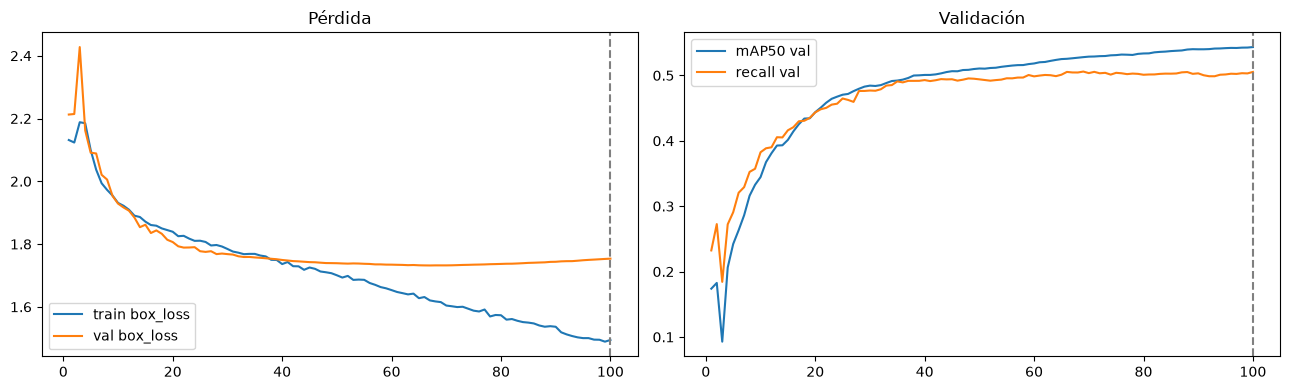

Mejor época por mAP50 de validación: 100


,epoch,train/box_loss,val/box_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B)
0,1,2.1315,2.2127,0.2782,0.2324,0.1739,0.0700
10,11,1.9221,1.9167,0.4488,0.3886,0.3674,0.1634
20,21,1.8251,1.7929,0.5264,0.4482,0.4506,0.2184
30,31,1.7762,1.7666,0.5463,0.4766,0.4838,0.2423
40,41,1.7428,1.7477,0.5574,0.4914,0.5008,0.2525
50,51,1.6933,1.7383,0.5734,0.4930,0.5103,0.2584
60,61,1.6474,1.7340,0.5808,0.4998,0.5201,0.2641
70,71,1.6019,1.7324,0.5818,0.5055,0.5289,0.2686
80,81,1.5592,1.7374,0.5977,0.5014,0.5337,0.2722
90,91,1.5189,1.7450,0.6128,0.5002,0.5400,0.2751


In [9]:
paso(f"Entrenamiento completo desde {inicio} (hasta {EPOCHS} épocas)")
t0 = time.time()
modelo = YOLO(inicio)
modelo.add_callback("on_fit_epoch_end", log_por_epoca("final"))
modelo.train(epochs=EPOCHS, patience=PATIENCE, name="bachemap_yolov8n", plots=True, cos_lr=True, **comun)
run_dir = WORK_DIR / "runs" / "bachemap_yolov8n"
best_pt = run_dir / "weights" / "best.pt"
min_entrenamiento = round((time.time() - t0) / 60, 1)
print(f"Entrenamiento: {min_entrenamiento} min | pesos: {best_pt} ({best_pt.stat().st_size / 1e6:.1f} MB)")

hist = pd.read_csv(run_dir / "results.csv")
hist.columns = hist.columns.str.strip()   # a veces vienen con espacios
mejor_epoca = int(hist.loc[hist["metrics/mAP50(B)"].idxmax(), "epoch"])

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(hist["epoch"], hist["train/box_loss"], label="train box_loss")
ax[0].plot(hist["epoch"], hist["val/box_loss"], label="val box_loss")
ax[0].set_title("Pérdida")
ax[1].plot(hist["epoch"], hist["metrics/mAP50(B)"], label="mAP50 val")
ax[1].plot(hist["epoch"], hist["metrics/recall(B)"], label="recall val")
ax[1].set_title("Validación")
for a in ax:
    a.axvline(mejor_epoca, ls="--", c="gray")
    a.legend()
plt.tight_layout()
plt.savefig(FIGS / "curvas_entrenamiento.png", dpi=110)
plt.show()
print("Mejor época por mAP50 de validación:", mejor_epoca)

# una fila cada 10 épocas; la evolución completa está en el gráfico
columnas = ["epoch", "train/box_loss", "val/box_loss", "metrics/precision(B)", "metrics/recall(B)",
            "metrics/mAP50(B)", "metrics/mAP50-95(B)"]
display(hist[columnas].iloc[::10].round(4))

### 5.4 Validación y elección del umbral de confianza
Ultralytics da el mAP, pero para elegir el umbral hacen falta precisión y recall a distintos umbrales, así que eso lo calculamos nosotros. Guardamos todas las predicciones con confianza ≥ 0,05 y las comparamos con las cajas reales:

- una predicción es un acierto si tiene la misma clase que una caja real y un IoU ≥ 0,5 con ella;
- las predicciones se recorren de mayor a menor confianza y cada caja real se puede usar una sola vez (si dos predicciones caen sobre el mismo bache, cuenta una).

De paso anotamos si cada predicción cae sobre algún daño real (IoU ≥ 0,3, sin importar la clase), porque eso hace falta en la etapa 2.

Como el orden es siempre el mismo, subir el umbral sólo saca predicciones del final de la lista. Entonces el emparejamiento se hace una vez y después, para cada umbral, alcanza con filtrar por confianza.

La regla quedó fijada antes de ver los resultados: el umbral es el que maximiza F2 en validación.


[00:26:16] Validación: predicciones y elección del umbral
   emparejando (val): 100%|███████████████████████████████| 19133/19133 [00:00<00:00, 149646.57it/s]


,umbral,precision,recall,F1,F2,TP,pred,reales
0,0.05,0.279,0.691,0.397,0.533,5336,19133,7725
1,0.10,0.427,0.614,0.504,0.565,4745,11109,7725
2,0.15,0.536,0.558,0.547,0.553,4309,8043,7725
3,0.20,0.615,0.505,0.555,0.524,3901,6340,7725
4,0.25,0.682,0.453,0.545,0.486,3502,5136,7725
5,0.30,0.734,0.407,0.523,0.447,3142,4279,7725
6,0.35,0.776,0.359,0.491,0.402,2772,3572,7725
7,0.40,0.813,0.320,0.459,0.364,2472,3042,7725
8,0.45,0.849,0.277,0.417,0.320,2138,2518,7725
9,0.50,0.873,0.238,0.373,0.278,1835,2101,7725


   calculando el mAP de validación...
Umbral elegido (máximo F2 en validación): 0.1 | mAP50 val = 0.543


,precision,recall,F1,reales
D00,0.413,0.609,0.492,3678
D10,0.393,0.620,0.481,1585
D20,0.513,0.694,0.590,1511
D40,0.414,0.497,0.452,951


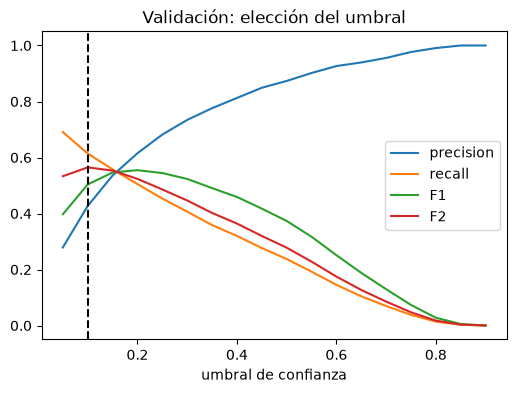

In [10]:
paso("Validación: predicciones y elección del umbral")
modelo = YOLO(best_pt)

def iou(a, b):   # IoU entre cajas (cx, cy, w, h) normalizadas
    ax1, ay1, ax2, ay2 = a[0] - a[2] / 2, a[1] - a[3] / 2, a[0] + a[2] / 2, a[1] + a[3] / 2
    bx1, by1, bx2, by2 = b[0] - b[2] / 2, b[1] - b[3] / 2, b[0] + b[2] / 2, b[1] + b[3] / 2
    ancho = min(ax2, bx2) - max(ax1, bx1)
    alto = min(ay2, by2) - max(ay1, by1)
    if ancho <= 0 or alto <= 0:
        return 0.0
    inter = ancho * alto
    union = a[2] * a[3] + b[2] * b[3] - inter
    return inter / union

def predecir(rutas):
    filas = []
    for i in barra(range(0, len(rutas), 64), f"prediciendo {len(rutas):,} imágenes"):
        # conf baja a propósito, el umbral se elige después
        resultados = modelo.predict(rutas[i:i + 64], conf=0.05, imgsz=IMGSZ, device=device, verbose=False)
        for r in resultados:
            cajas = r.boxes.xywhn.tolist()
            confianzas = r.boxes.conf.tolist()
            clases = r.boxes.cls.tolist()
            for (cx, cy, w, h), conf, k in zip(cajas, confianzas, clases):
                filas.append({"ruta_yolo": r.path, "clase_pred": CLASES[int(k)], "confianza": conf,
                              "cx": cx, "cy": cy, "w": w, "h": h})
    return pd.DataFrame(filas, columns=["ruta_yolo", "clase_pred", "confianza", "cx", "cy", "w", "h"])

def emparejar(pred, split):   # agrega tp, danio_real, clase_real (ver arriba)
    pred = pred.copy()
    ruta_a_id = dict(zip(imgs_df["ruta_yolo"], imgs_df["img_id"]))
    pred["img_id"] = pred["ruta_yolo"].map(ruta_a_id)
    assert pred["img_id"].notna().all(), "hay predicciones con una ruta que no está en imgs_df"
    pred = pred.sort_values("confianza", ascending=False).reset_index(drop=True)

    ids_split = imgs_df.loc[imgs_df["split"] == split, "img_id"]
    gt = cajas_df[cajas_df["img_id"].isin(ids_split)]
    # cajas reales de cada imagen: {img_id: [(clase, (cx, cy, w, h)), ...]}
    reales_por_img = {}
    for img_id, clase, cx, cy, w, h in gt[["img_id", "clase", "cx", "cy", "w", "h"]].itertuples(index=False):
        reales_por_img.setdefault(img_id, []).append((clase, (cx, cy, w, h)))

    usadas = set()   # cajas reales ya asignadas
    tp, danio_real, clase_real = [], [], []
    filas = pred[["img_id", "clase_pred", "cx", "cy", "w", "h"]].itertuples(index=False)
    for img_id, clase_pred, cx, cy, w, h in barra(filas, f"emparejando ({split})", total=len(pred)):
        caja = (cx, cy, w, h)
        reales = reales_por_img.get(img_id, [])

        # daño real: la caja real de mayor IoU, sin importar la clase
        mejor_iou, mejor_clase = 0, None
        for clase_gt, caja_gt in reales:
            v = iou(caja, caja_gt)
            if v > mejor_iou:
                mejor_iou, mejor_clase = v, clase_gt
        danio_real.append(1 if mejor_iou >= 0.3 else 0)
        clase_real.append(mejor_clase if mejor_iou >= 0.3 else None)

        # acierto: entre las cajas libres de la misma clase, la de mayor IoU (mínimo 0.5)
        elegida, iou_elegida = None, 0
        for k, (clase_gt, caja_gt) in enumerate(reales):
            if clase_gt != clase_pred or (img_id, k) in usadas:
                continue
            v = iou(caja, caja_gt)
            if v >= 0.5 and v > iou_elegida:
                elegida, iou_elegida = k, v
        if elegida is None:
            tp.append(0)
        else:
            usadas.add((img_id, elegida))
            tp.append(1)

    pred["tp"] = tp
    pred["danio_real"] = danio_real
    pred["clase_real"] = clase_real
    return pred, gt

def metricas(pred, gt, umbral, clase=None):   # precisión/recall/F1/F2 a un umbral dado
    p = pred[pred["confianza"] >= umbral]
    n_reales = len(gt)
    if clase is not None:
        p = p[p["clase_pred"] == clase]
        n_reales = int((gt["clase"] == clase).sum())
    aciertos = int(p["tp"].sum())
    precision = aciertos / len(p) if len(p) > 0 else 0.0
    recall = aciertos / n_reales if n_reales > 0 else 0.0
    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
        f2 = 5 * precision * recall / (4 * precision + recall)
    else:
        f1 = f2 = 0.0
    return {"umbral": umbral, "precision": precision, "recall": recall, "F1": f1, "F2": f2,
            "TP": aciertos, "pred": len(p), "reales": n_reales}

val_rutas = imgs_df.loc[imgs_df["split"] == "val", "ruta_yolo"].tolist()
pred_val, gt_val = emparejar(predecir(val_rutas), "val")

umbrales = [round(0.05 * k, 2) for k in range(1, 19)]   # 0.05, 0.10, ..., 0.90
curva_val = pd.DataFrame([metricas(pred_val, gt_val, u) for u in umbrales])
umbral = float(curva_val.loc[curva_val["F2"].idxmax(), "umbral"])
display(curva_val.round(3))

print("   calculando el mAP de validación...", flush=True)
met_val = modelo.val(data=str(data_yaml), split="val", imgsz=IMGSZ, batch=BATCH, device=device, verbose=False, plots=False)
map_val = {"mAP50": float(met_val.box.map50), "mAP50_95": float(met_val.box.map)}
print(f"Umbral elegido (máximo F2 en validación): {umbral} | mAP50 val = {map_val['mAP50']:.3f}")

por_clase_val = pd.DataFrame([metricas(pred_val, gt_val, umbral, c) for c in CLASES], index=CLASES)
display(por_clase_val[["precision", "recall", "F1", "reales"]].round(3))

plt.figure(figsize=(6, 4))
for col in ["precision", "recall", "F1", "F2"]:
    plt.plot(curva_val["umbral"], curva_val[col], label=col)
plt.axvline(umbral, ls="--", c="k")
plt.xlabel("umbral de confianza")
plt.legend()
plt.title("Validación: elección del umbral")
plt.savefig(FIGS / "umbral_validacion.png", dpi=110)
plt.show()

## 6. Etapa 2 · Prioridad de reparación (`Pipeline` + `ColumnTransformer`)
Saber que hay un bache no alcanza: la Dirección de Vialidad necesita saber cuál arreglar primero. Para eso cada detección pasa a ser una fila de una tabla, con datos que se pueden observar en producción: la clase predicha, la confianza, el tamaño de la caja (área relativa y relación de aspecto), en qué parte de la foto está (más abajo quiere decir más cerca de la cámara), cuántas detecciones hay en esa foto, el tipo de vía y el barrio.

El contexto geográfico es **simulado**, y conviene dejarlo claro. RDD2022 no tiene fotos de Asunción, así que asignamos cada imagen a un tramo inventado dentro de un barrio real (con coordenadas aproximadas) y a un tipo de vía. En producción la ubicación saldría del GPS del teléfono y el tipo de vía de la cartografía municipal.

El target, `prioridad`, tampoco viene de inspectores. Lo armamos con una regla que usa información que el modelo no ve, que es si la detección cae sobre un daño real y de qué clase es:
* si es una falsa alarma, `baja`;
* si no, se suman puntos: la severidad de la clase real (bache 3, piel de cocodrilo 2, grietas 1), +1 si la caja ocupa al menos el 2 % de la foto y otro +1 si ocupa el 8 %, y +1 si la vía es arterial;
* con 4 puntos o más es `alta`, con 2 o 3 es `media` y con menos es `baja`. Además a un 5 % de las filas se les cambia la etiqueta al azar, como si fueran desacuerdos entre inspectores.

Con etiquetas así las métricas van a salir altas, y no hay que leer mucho en eso: el modelo aprende a reproducir nuestra regla, no el criterio de un inspector.

Otra cosa: el modelo de prioridad se entrena con las detecciones de **validación**, no con las de train. Sobre train YOLO ya está sobreajustado y las confianzas le salen demasiado optimistas, y preferimos que aprenda de detecciones parecidas a las que va a ver después. El test sigue sin tocarse.

In [14]:
paso("Etapa 2: contexto geográfico simulado y tabla de detecciones")
rng_geo = np.random.default_rng(SEED)

# centros de barrios de Asunción, para la simulación
barrios = {"Centro": (-25.2830, -57.6360), "Sajonia": (-25.2940, -57.6480), "Recoleta": (-25.2920, -57.6090),
           "Villa Morra": (-25.2940, -57.5770), "Carmelitas": (-25.2850, -57.5730), "Trinidad": (-25.2590, -57.5950),
           "San Vicente": (-25.3120, -57.6060), "Barrio Obrero": (-25.3160, -57.6250), "Mburucuyá": (-25.2800, -57.5790),
           "Las Mercedes": (-25.2930, -57.6230)}
tipos_via = ["arterial", "colectora", "local"]

# 3 tramos por barrio, tipo de vía al azar
filas_tramos = []
for barrio, (lat, lon) in barrios.items():
    for k in range(3):
        filas_tramos.append({"tramo_id": f"{barrio}-{k}", "barrio": barrio,
                             "lat": lat + rng_geo.normal(0, 0.004), "lon": lon + rng_geo.normal(0, 0.004),
                             "tipo_via": rng_geo.choice(tipos_via, p=[0.3, 0.3, 0.4])})
tramos = pd.DataFrame(filas_tramos)

# cada imagen a un tramo al azar
asig = rng_geo.integers(0, len(tramos), len(imgs_df))
imgs_df["tramo_id"] = tramos["tramo_id"].values[asig]
imgs_df["barrio"] = tramos["barrio"].values[asig]
imgs_df["tipo_via"] = tramos["tipo_via"].values[asig]
imgs_df["lat"] = tramos["lat"].values[asig] + rng_geo.normal(0, 0.0006, len(imgs_df))
imgs_df["lon"] = tramos["lon"].values[asig] + rng_geo.normal(0, 0.0006, len(imgs_df))

features_num = ["confianza", "area_rel", "aspecto", "cy_rel", "cx_rel", "n_det_imagen"]
features_cat = ["clase_pred", "tipo_via", "barrio"]
severidad = {"D40": 3, "D20": 2, "D10": 1, "D00": 1}

def regla_prioridad(fila):   # ver sección 6; usa danio_real/clase_real, que el modelo no ve
    if fila["danio_real"] == 0:
        return "baja"   # falsa alarma
    puntos = severidad[fila["clase_real"]]
    if fila["area_rel"] >= 0.02:
        puntos += 1
    if fila["area_rel"] >= 0.08:
        puntos += 1
    if fila["tipo_via"] == "arterial":
        puntos += 1
    if puntos >= 4:
        return "alta"
    if puntos >= 2:
        return "media"
    return "baja"

def a_tabla(pred, umbral, rng):   # detecciones con confianza >= umbral -> features + prioridad
    d = pred[pred["confianza"] >= umbral].copy()
    d = d.merge(imgs_df[["img_id", "pais", "tramo_id", "barrio", "tipo_via", "lat", "lon", "split"]],
                on="img_id", how="left")
    d["area_rel"] = d["w"] * d["h"]
    d["aspecto"] = d["w"] / d["h"].clip(lower=1e-6)   # evita dividir por cero
    d["cy_rel"] = d["cy"]
    d["cx_rel"] = d["cx"]
    d["n_det_imagen"] = d.groupby("img_id")["confianza"].transform("size")

    prioridad = d.apply(regla_prioridad, axis=1).to_numpy()
    cambiar = rng.random(len(d)) < 0.05   # simula desacuerdo entre inspectores
    prioridad[cambiar] = rng.choice(["alta", "media", "baja"], cambiar.sum())
    d["prioridad"] = prioridad

    # jitter de unos 5 m por detección, dentro del mismo tramo
    d["lat"] += rng.normal(0, 0.00005, len(d))
    d["lon"] += rng.normal(0, 0.00005, len(d))
    return d

tabla_val = a_tabla(pred_val, umbral, np.random.default_rng(SEED + 1))
print(f"Detecciones de validación con confianza ≥ {umbral}: {len(tabla_val):,}")
display(tabla_val["prioridad"].value_counts(normalize=True).round(3))
display(tabla_val[features_num + features_cat + ["prioridad"]].head())


[00:27:50] Etapa 2: contexto geográfico simulado y tabla de detecciones
Detecciones de validación con confianza ≥ 0.1: 11,109


prioridad
baja     0.472
media    0.363
alta     0.164
Name: proportion, dtype: float64

,confianza,area_rel,aspecto,cy_rel,cx_rel,n_det_imagen,clase_pred,tipo_via,barrio,prioridad
0,0.901786,0.840582,1.184253,0.577791,0.498864,1,D20,arterial,Trinidad,alta
1,0.884827,0.022060,0.391872,0.877065,0.253252,4,D00,arterial,Trinidad,baja
2,0.877869,0.020428,0.703570,0.596944,0.426680,3,D40,colectora,Villa Morra,alta
3,0.875506,0.036454,0.387988,0.842759,0.321058,22,D00,local,Villa Morra,media
4,0.873908,0.645048,1.527396,0.672956,0.498446,2,D20,local,Villa Morra,alta


### 6.1 Qué modelo usar
Probamos dos candidatos, una regresión logística y un random forest, cada uno dentro de un `Pipeline` con el mismo preprocesamiento:

* En el `ColumnTransformer` las numéricas se imputan con la mediana y, sólo para la logística, se escalan (a los árboles el escalado no les cambia nada). Las categóricas se imputan y pasan por un `OneHotEncoder(handle_unknown="ignore")`, así un barrio que no apareció en el entrenamiento no rompe la predicción.
* `class_weight="balanced"`, porque `alta` es la clase chica. Es lo primero que conviene probar antes de pensar en re-muestrear.
* Validación cruzada agrupada por imagen (`StratifiedGroupKFold`). Las detecciones de una misma foto se parecen mucho entre sí, y si quedan en folds distintos el modelo se evalúa con datos que casi ya vio.

Gana el de mayor F2 en la clase `alta`, promediado sobre los folds.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import make_scorer, fbeta_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay

def preprocesador(escalar):
    pasos_num = [("imputar", SimpleImputer(strategy="median"))]
    if escalar:
        pasos_num.append(("escalar", StandardScaler()))
    pasos_cat = [("imputar", SimpleImputer(strategy="most_frequent")),
                 ("onehot", OneHotEncoder(handle_unknown="ignore"))]
    return ColumnTransformer([("num", Pipeline(pasos_num), features_num),
                              ("cat", Pipeline(pasos_cat), features_cat)])

candidatos = {
    "regresion_logistica": Pipeline([("prep", preprocesador(escalar=True)),
                                     ("modelo", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "random_forest": Pipeline([("prep", preprocesador(escalar=False)),
                               ("modelo", RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                                                 class_weight="balanced", random_state=SEED, n_jobs=-1))]),
}
X_val = tabla_val[features_num + features_cat]
y_val = tabla_val["prioridad"]
grupos_val = tabla_val["img_id"]

# scikit-learn 1.8 pide pos_label en multiclase, de ahí los scorers propios
def f2_alta(y, p):     return fbeta_score(y, p, beta=2, labels=["alta"], average="macro", zero_division=0)
def recall_alta(y, p): return recall_score(y, p, labels=["alta"], average="macro", zero_division=0)
def f1_macro(y, p):    return f1_score(y, p, average="macro", zero_division=0)
scoring = {"F2_alta": make_scorer(f2_alta), "recall_alta": make_scorer(recall_alta), "F1_macro": make_scorer(f1_macro)}

n_folds = 2 if MODO_PRUEBA else 5
cv = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
paso(f"Etapa 2: validación cruzada agrupada ({n_folds} folds) sobre {len(X_val):,} detecciones")
res_cv = {}
for nombre, pipe in candidatos.items():
    t0 = time.time()
    r = cross_validate(pipe, X_val, y_val, groups=grupos_val, cv=cv, scoring=scoring, error_score="raise")
    res_cv[nombre] = {"F2_alta": r["test_F2_alta"].mean(), "recall_alta": r["test_recall_alta"].mean(),
                      "F1_macro": r["test_F1_macro"].mean()}
    print(f"   {nombre}: F2(alta) = {res_cv[nombre]['F2_alta']:.3f} ({time.time() - t0:.0f} s)", flush=True)
res_cv = pd.DataFrame(res_cv).T.round(3)
display(res_cv)

ganador_prio = res_cv["F2_alta"].idxmax()
pipe_prioridad = candidatos[ganador_prio].fit(X_val, y_val)
print("Modelo de prioridad elegido:", ganador_prio)


[00:27:50] Etapa 2: validación cruzada agrupada (5 folds) sobre 11,109 detecciones
   regresion_logistica: F2(alta) = 0.809 (2 s)
   random_forest: F2(alta) = 0.870 (4 s)


,F2_alta,recall_alta,F1_macro
regresion_logistica,0.809,0.846,0.711
random_forest,0.870,0.892,0.795


Modelo de prioridad elegido: random_forest


## 7. Decisiones congeladas en `selection.json`
Antes de abrir el test dejamos escrito todo lo que se decidió con validación, así después no hay tentación de cambiar nada.

In [16]:
paso("Guardando las decisiones en selection.json")
seleccion = {
    "fecha": time.strftime("%Y-%m-%d %H:%M"),
    "n_imagenes": imgs_df["split"].value_counts().to_dict(),
    "split": "el que trae el dataset (RDD_SPLIT)",
    "paises_excluidos": ["China_Drone"],
    "detector": {"arquitectura": "YOLOv8n", "inicializacion": inicio, "comparacion_transfer": transfer,
                 "mejor_epoca": mejor_epoca, "imgsz": IMGSZ, "augmentation": aug, "minutos": min_entrenamiento,
                 "umbral_confianza": umbral, "regla_umbral": "máximo F2 en validación",
                 "mAP50_val": round(map_val["mAP50"], 4)},
    "prioridad": {"modelo": ganador_prio, "regla": "máximo F2(alta) en CV agrupada por imagen",
                  "cv": res_cv.to_dict()},
}
with open(WORK_DIR / "artefactos" / "selection.json", "w") as f:
    json.dump(seleccion, f, indent=2, default=str)
print(json.dumps(seleccion, indent=2, default=str))


[00:28:07] Guardando las decisiones en selection.json
{
  "fecha": "2026-09-24 00:28",
  "n_imagenes": {
    "train": 25194,
    "val": 5409,
    "test": 5381
  },
  "split": "el que trae el dataset (RDD_SPLIT)",
  "paises_excluidos": [
    "China_Drone"
  ],
  "detector": {
    "arquitectura": "YOLOv8n",
    "inicializacion": "yolov8n.pt",
    "comparacion_transfer": {
      "preentrenado_COCO": {
        "mAP50_val": 0.1547,
        "mAP50_95_val": 0.0617,
        "minutos": 5.6
      },
      "desde_cero": {
        "mAP50_val": 0.0064,
        "mAP50_95_val": 0.0017,
        "minutos": 5.6
      }
    },
    "mejor_epoca": 100,
    "imgsz": 640,
    "augmentation": {
      "fliplr": 0.5,
      "flipud": 0.0,
      "hsv_h": 0.015,
      "hsv_s": 0.5,
      "hsv_v": 0.4,
      "mosaic": 1.0,
      "close_mosaic": 10
    },
    "minutos": 277.8,
    "umbral_confianza": 0.1,
    "regla_umbral": "m\u00e1ximo F2 en validaci\u00f3n",
    "mAP50_val": 0.5429
  },
  "prioridad": {
    "mod

## 8. Test
Ahora sí se abre el test, una sola vez y con todo lo anterior ya anotado. Lo que salga acá es lo que reportamos, sin volver atrás a ajustar nada.

In [17]:
paso("Test")
print("   calculando el mAP de test...", flush=True)
met_test = modelo.val(data=str(data_yaml), split="test", imgsz=IMGSZ, batch=BATCH, device=device,
                      verbose=False, plots=True, project=str(WORK_DIR / "runs"), name="test_final", exist_ok=True)
test_rutas = imgs_df.loc[imgs_df["split"] == "test", "ruta_yolo"].tolist()
pred_test, gt_test = emparejar(predecir(test_rutas), "test")

global_test = metricas(pred_test, gt_test, umbral)
por_clase_test = pd.DataFrame([metricas(pred_test, gt_test, umbral, c) for c in CLASES], index=CLASES)
# AP50 por clase, tomado de la validación de Ultralytics
ap50 = {}
for i, v in zip(met_test.box.ap_class_index, met_test.box.ap50):
    ap50[CLASES[int(i)]] = float(v)
por_clase_test["AP50"] = pd.Series(ap50)

resultados_test = {
    "mAP50": round(float(met_test.box.map50), 4),
    "mAP50_95": round(float(met_test.box.map), 4),
    "precision": round(global_test["precision"], 4),
    "recall": round(global_test["recall"], 4),
    "F1": round(global_test["F1"], 4),
    "recall_D40": round(float(por_clase_test.loc["D40", "recall"]), 4),
}
print("Test con umbral", umbral, ":", resultados_test)
display(por_clase_test[["AP50", "precision", "recall", "F1", "reales"]].round(3))
print(f"Diferencia val − test en mAP50: {map_val['mAP50'] - resultados_test['mAP50']:+.3f}")


[00:28:15] Test
   calculando el mAP de test...
   emparejando (test): 100%|██████████████████████████████| 18897/18897 [00:00<00:00, 153902.15it/s]
Test con umbral 0.1 : {'mAP50': 0.5482, 'mAP50_95': 0.2782, 'precision': 0.4238, 'recall': 0.6183, 'F1': 0.5029, 'recall_D40': 0.5085}


,AP50,precision,recall,F1,reales
D00,0.551,0.419,0.611,0.497,3693
D10,0.507,0.373,0.631,0.469,1475
D20,0.671,0.503,0.694,0.583,1493
D40,0.463,0.414,0.508,0.457,942


Diferencia val − test en mAP50: -0.005


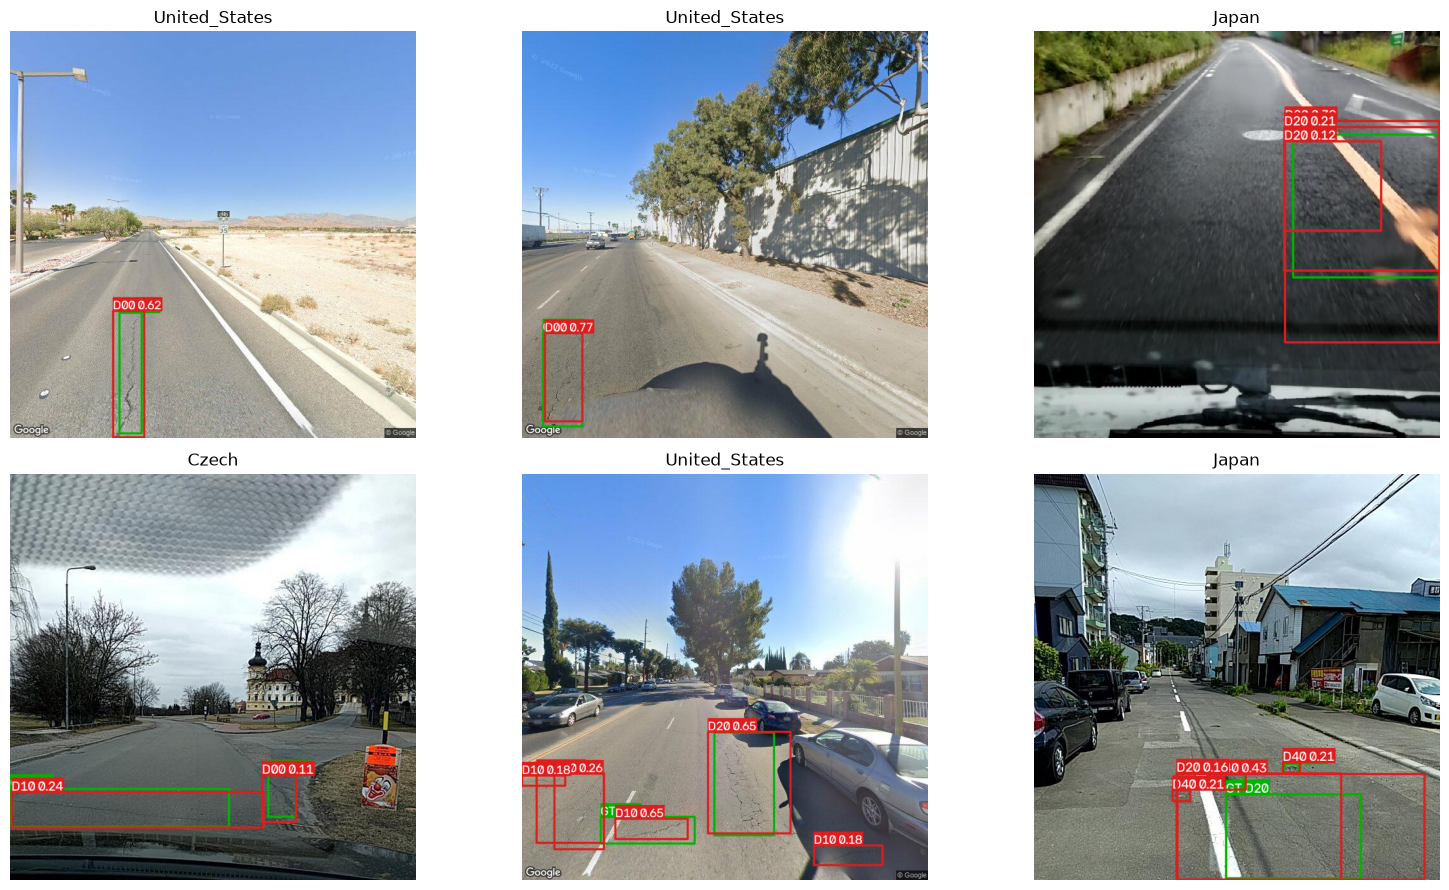

In [18]:
# verde = anotación real, rojo = predicción
from ultralytics.utils.plotting import Annotator

def a_pixeles(cx, cy, w, h, W, H):   # normalizada -> píxeles [x1, y1, x2, y2]
    return [(cx - w / 2) * W, (cy - h / 2) * H, (cx + w / 2) * W, (cy + h / 2) * H]

con_danio = imgs_df[(imgs_df["split"] == "test") & (imgs_df["n_cajas"] > 0)]
ejemplos = con_danio.sample(min(6, len(con_danio)), random_state=SEED)
fig, axs = plt.subplots(2, 3, figsize=(16, 9))
for ax, (_, r) in zip(axs.flat, ejemplos.iterrows()):
    im = np.array(Image.open(r["ruta_yolo"]).convert("RGB"))
    H, W = im.shape[:2]
    an = Annotator(im.copy(), line_width=2)
    for _, b in cajas_df[cajas_df["img_id"] == r["img_id"]].iterrows():
        an.box_label(a_pixeles(b["cx"], b["cy"], b["w"], b["h"], W, H), f"GT {b['clase']}", color=(0, 180, 0))
    det = pred_test[(pred_test["img_id"] == r["img_id"]) & (pred_test["confianza"] >= umbral)]
    for _, p in det.iterrows():
        etiqueta = f"{p['clase_pred']} {p['confianza']:.2f}"
        an.box_label(a_pixeles(p["cx"], p["cy"], p["w"], p["h"], W, H), etiqueta, color=(220, 30, 30))
    ax.imshow(an.result())
    ax.set_title(r["pais"])
    ax.axis("off")
plt.tight_layout()
plt.savefig(FIGS / "ejemplos_test.png", dpi=100)
plt.show()


[00:29:56] Etapa 2 en test
              precision    recall  f1-score   support

        alta      0.779     0.889     0.831      1808
        baja      0.907     0.634     0.746      5123
       media      0.698     0.914     0.791      4162

    accuracy                          0.780     11093
   macro avg      0.795     0.812     0.789     11093
weighted avg      0.808     0.780     0.777     11093



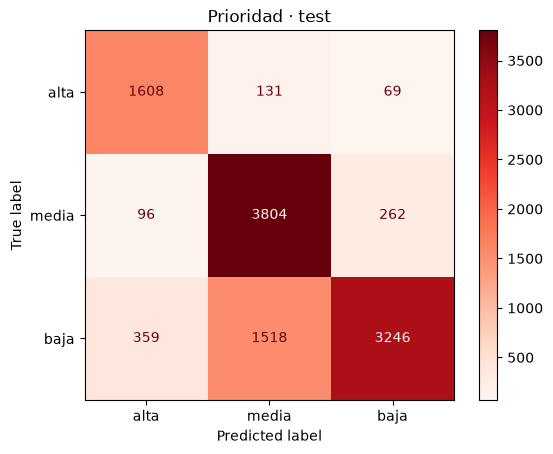

Prioridad en test: {'recall_alta': 0.8894, 'F2_alta': 0.865, 'F1_macro': 0.7894}


In [19]:
paso("Etapa 2 en test")
tabla_test = a_tabla(pred_test, umbral, np.random.default_rng(SEED + 2))
y_test = tabla_test["prioridad"]
y_pred_test = pipe_prioridad.predict(tabla_test[features_num + features_cat])
print(classification_report(y_test, y_pred_test, digits=3))
prio_test = {"recall_alta": round(recall_alta(y_test, y_pred_test), 4),
             "F2_alta": round(f2_alta(y_test, y_pred_test), 4),
             "F1_macro": round(f1_macro(y_test, y_pred_test), 4)}
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, labels=["alta", "media", "baja"], cmap="Reds")
plt.title("Prioridad · test")
plt.savefig(FIGS / "prioridad_test.png", dpi=110)
plt.show()
print("Prioridad en test:", prio_test)

## 9. Focos geográficos con DBSCAN
Por último, agrupamos en focos las detecciones urgentes del test (prioridad `alta` o `media`), para que una cuadrilla pueda salir a cubrir una zona entera. Elegimos DBSCAN con distancia haversine por dos motivos: no hay que decirle de antemano cuántos focos hay, y los daños aislados quedan como ruido en vez de meterlos a la fuerza en algún grupo. Los parámetros son `eps` = 100 m y `min_samples` = 5.

Como los tramos son inventados, sabemos a qué tramo pertenece cada detección y podemos medir el ARI contra eso. Pero es un control de laboratorio: muestra que el agrupamiento funciona, no que vaya a funcionar igual en calles de verdad.


[00:29:57] Focos geográficos con DBSCAN
Focos: 21 | ruido: 0.0% | ARI contra los tramos simulados: 0.731


,detecciones,alta,baches,barrio,tipo_via,lat,lon
foco,,,,,,,
2,988,292,122,Trinidad,arterial,-25.257284,-57.594211
0,637,219,95,Sajonia,local,-25.297494,-57.645803
9,529,157,73,Centro,arterial,-25.282166,-57.638390
14,536,153,56,San Vicente,colectora,-25.315653,-57.607319
12,550,151,54,Las Mercedes,arterial,-25.294299,-57.622512
4,466,144,57,Carmelitas,arterial,-25.285439,-57.577320
11,422,138,42,Barrio Obrero,arterial,-25.313104,-57.621813
19,368,114,34,Mburucuyá,arterial,-25.285099,-57.583530
5,311,92,26,Villa Morra,arterial,-25.297301,-57.574590


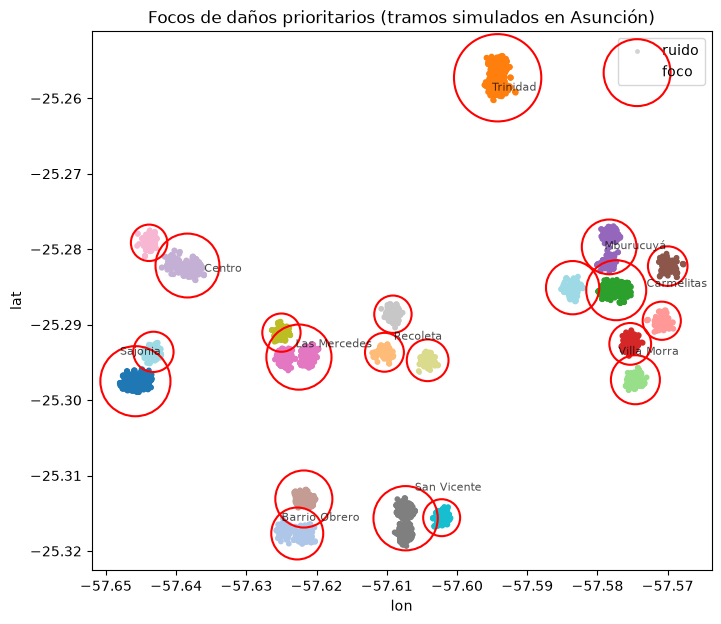

In [20]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import adjusted_rand_score

paso("Focos geográficos con DBSCAN")
eps_m, min_samples = 100, 5
tabla_test["prioridad_pred"] = y_pred_test
urg = tabla_test[tabla_test["prioridad_pred"].isin(["alta", "media"])].copy()

# haversine trabaja en radianes: eps se expresa como metros / radio terrestre
dbscan = DBSCAN(eps=eps_m / 6_371_000, min_samples=min_samples, metric="haversine")
urg["foco"] = dbscan.fit_predict(np.radians(urg[["lat", "lon"]].values))

aislados = urg[urg["foco"] == -1]
con_foco = urg[urg["foco"] >= 0].copy()
ari_focos = adjusted_rand_score(con_foco["tramo_id"], con_foco["foco"])

con_foco["es_alta"] = (con_foco["prioridad_pred"] == "alta").astype(int)
con_foco["es_bache"] = (con_foco["clase_pred"] == "D40").astype(int)
focos = con_foco.groupby("foco").agg(detecciones=("foco", "size"), alta=("es_alta", "sum"),
                                     baches=("es_bache", "sum"), barrio=("barrio", "first"),
                                     tipo_via=("tipo_via", "first"), lat=("lat", "mean"), lon=("lon", "mean"))
focos = focos.sort_values(["alta", "detecciones"], ascending=False)
print(f"Focos: {len(focos)} | ruido: {len(aislados) / len(urg):.1%} | ARI contra los tramos simulados: {ari_focos:.3f}")
display(focos.head(10))

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(aislados["lon"], aislados["lat"], s=6, c="lightgray", label="ruido")
ax.scatter(con_foco["lon"], con_foco["lat"], s=10, c=con_foco["foco"], cmap="tab20")
ax.scatter(focos["lon"], focos["lat"], s=focos["detecciones"] * 4, facecolors="none", edgecolors="red",
           lw=1.5, label="foco")
for b, (la, lo) in barrios.items():
    ax.annotate(b, (lo, la), fontsize=8, alpha=0.7)
ax.set_title("Focos de daños prioritarios (tramos simulados en Asunción)")
ax.set_xlabel("lon")
ax.set_ylabel("lat")
ax.legend()
plt.savefig(FIGS / "focos_dbscan.png", dpi=110)
plt.show()

## 10. Guardado del modelo con `joblib`
`model.pkl` en realidad es un diccionario con todo lo que necesita la app: los bytes de los pesos de YOLO, el `Pipeline` de scikit-learn, los parámetros de DBSCAN y algunos metadatos. Como son todos objetos estándar (no hay clases propias adentro), `joblib.load()` lo abre en cualquier entorno con las mismas versiones. Las versiones quedan anotadas también en `metadata.json`.

In [21]:
paso("Guardando model.pkl")
bundle = {
    "nombre": "BacheMap v1",
    "yolo_pt_bytes": best_pt.read_bytes(), "yolo_imgsz": IMGSZ, "umbral_confianza": umbral,
    "clases": CLASES, "nombres_es": NOMBRES_ES,
    "pipeline_prioridad": pipe_prioridad, "features_num": features_num, "features_cat": features_cat,
    "dbscan": {"eps_m": eps_m, "min_samples": min_samples},
    "barrios": barrios, "tipos_via": tipos_via,
    "metricas": {"test_detector": resultados_test, "test_prioridad": prio_test, "val_mAP50": map_val["mAP50"]},
    "seleccion": seleccion, "versiones": versiones,
}
model_pkl = WORK_DIR / "model.pkl"
joblib.dump(bundle, model_pkl, compress=3)
with open(WORK_DIR / "metadata.json", "w") as f:
    json.dump({"versiones": versiones, "umbral": umbral, "metricas": bundle["metricas"]}, f, indent=2)
print(f"model.pkl: {model_pkl.stat().st_size / 1e6:.2f} MB (el ZIP de la entrega no puede pasar de 20 MB)")


[00:29:57] Guardando model.pkl
model.pkl: 18.64 MB (el ZIP de la entrega no puede pasar de 20 MB)


### 10.1 Recarga rápida
Antes de dar el `model.pkl` por bueno, lo volvemos a cargar desde el archivo (sin usar nada de lo que quedó en memoria) y corremos una predicción de prueba, para confirmar que el bundle funciona solo.

In [22]:
import tempfile

paso("Recarga rápida del bundle")
bundle_cargado = joblib.load(model_pkl)
tmp_pt = Path(tempfile.gettempdir()) / "bachemap_yolo.pt"
tmp_pt.write_bytes(bundle_cargado["yolo_pt_bytes"])
yolo_cargado = YOLO(str(tmp_pt))

prueba = yolo_cargado.predict(test_rutas[0], conf=bundle_cargado["umbral_confianza"], imgsz=IMGSZ,
                              device=device, verbose=False)[0]
print(f"Recargado desde {model_pkl.name}: {len(prueba.boxes)} detecciones en la primera imagen de test")


[00:29:58] Recarga rápida del bundle
Recargado desde model.pkl: 6 detecciones en la primera imagen de test


## 11. `datos_muestra.csv`
Cien detecciones del test elegidas al azar, con las columnas que usa el `Pipeline` más la prioridad y la ubicación.

In [23]:
paso("datos_muestra.csv")
columnas = ["img_id", "pais"] + features_cat + features_num + ["lat", "lon", "prioridad"]
muestra_df = tabla_test.sample(min(100, len(tabla_test)), random_state=SEED)
muestra_df[columnas].round(5).to_csv(WORK_DIR / "datos_muestra.csv", index=False)
print("datos_muestra.csv:", muestra_df[columnas].shape)
print(muestra_df["prioridad"].value_counts().to_dict())
display(muestra_df[columnas].head())


[00:29:58] datos_muestra.csv
datos_muestra.csv: (100, 14)
{'baja': 42, 'media': 42, 'alta': 16}


,img_id,pais,clase_pred,tipo_via,barrio,confianza,area_rel,aspecto,cy_rel,cx_rel,n_det_imagen,lat,lon,prioridad
1891,Japan_011081,Japan,D20,arterial,Mburucuyá,0.516782,0.070013,2.854263,0.640310,0.299109,5,-25.284974,-57.582768,alta
9165,Norway_003137,Norway,D00,local,Trinidad,0.126587,0.000884,0.167229,0.657483,0.484264,18,-25.258249,-57.593582,baja
3902,Japan_010368,Japan,D10,arterial,Barrio Obrero,0.322140,0.006051,5.256476,0.893899,0.842344,8,-25.312786,-57.621171,media
10214,India_008168,India,D20,local,Centro,0.110532,0.055701,1.022296,0.847580,0.717052,1,-25.281391,-57.641158,baja
883,United_States_004778,United_States,D10,arterial,Trinidad,0.645608,0.008777,5.871260,0.858405,0.686627,3,-25.258018,-57.593851,media


## 12. ROI estimado (tres escenarios)
La cuenta es sencilla. Un bache que se detecta temprano se repara cuando todavía es chico, y eso ahorra asfalto:

ahorro anual = baches por año × cobertura del relevamiento × recall de baches (el medido en test) × m² por bache × reducción del área a reparar × costo por m²

y a eso se le resta lo que cuesta operar el sistema.

Algunos números salen de la Municipalidad de Asunción (asuncion.gov.py). En agosto de 2026 hubo 3.574 bacheos, o sea unos 42.900 por año. 1.717 bacheos cubrieron unos 6.600 m², lo que da 3,8 m² por bache. Y en 2024 se destinaron 48.000 millones de guaraníes a 157.350 m² de regularización asfáltica y bacheo: unos 305.000 Gs/m², aunque eso es una cota superior porque mezcla los dos trabajos.

El resto (cobertura, reducción de área, costo del sistema) son supuestos nuestros que habría que validar con la Dirección de Vialidad. Por eso hay tres escenarios y no uno.

In [25]:
paso("ROI en tres escenarios")
baches_anio = 3574 * 12
m2_por_bache = 6600 / 1717
recall_d40 = resultados_test["recall_D40"]
escenarios = {
    "pesimista": {"cobertura": 0.20, "reduccion_area": 0.10, "costo_m2_gs": 150_000, "costo_sistema_gs": 250_000_000},
    "base":      {"cobertura": 0.40, "reduccion_area": 0.20, "costo_m2_gs": 250_000, "costo_sistema_gs": 200_000_000},
    "optimista": {"cobertura": 0.60, "reduccion_area": 0.30, "costo_m2_gs": 305_000, "costo_sistema_gs": 150_000_000},
}
filas = []
for nombre, e in escenarios.items():
    m2 = baches_anio * e["cobertura"] * recall_d40 * m2_por_bache * e["reduccion_area"]
    ahorro = m2 * e["costo_m2_gs"]
    beneficio = ahorro - e["costo_sistema_gs"]
    fila = dict(e)
    fila["escenario"] = nombre
    fila["m2_ahorrados"] = round(m2)
    fila["ahorro_gs"] = round(ahorro)
    fila["beneficio_neto_gs"] = round(beneficio)
    fila["ROI"] = round(beneficio / e["costo_sistema_gs"], 2)
    filas.append(fila)
roi_df = pd.DataFrame(filas).set_index("escenario")
pd.options.display.float_format = "{:,.2f}".format
display(roi_df)
print(f"Recall de baches usado (medido en test): {recall_d40:.3f}. ROI = (ahorro − costo) / costo.")

# la app muestra esta tabla, así que se agrega al bundle y se vuelve a guardar
bundle["roi"] = roi_df.reset_index().to_dict("records")
joblib.dump(bundle, model_pkl, compress=3)
print("model.pkl regrabado con la tabla de ROI")


[00:33:51] ROI en tres escenarios


,cobertura,reduccion_area,costo_m2_gs,costo_sistema_gs,m2_ahorrados,ahorro_gs,beneficio_neto_gs,ROI
escenario,,,,,,,,
pesimista,0.20,0.10,150000,250000000,1677,251490536,1490536,0.01
base,0.40,0.20,250000,200000000,6706,1676603574,1476603574,7.38
optimista,0.60,0.30,305000,150000000,15089,4602276810,4452276810,29.68


Recall de baches usado (medido en test): 0.508. ROI = (ahorro − costo) / costo.
model.pkl regrabado con la tabla de ROI


## 13. Resumen, límites y próximos pasos

In [27]:
paso("Resumen final")
resumen_final = {
    "detector_test": resultados_test, "prioridad_test": prio_test, "umbral": umbral,
    "mAP50_val": round(map_val["mAP50"], 4), "focos_dbscan": len(focos), "ARI_focos_laboratorio": round(ari_focos, 3),
    "ROI_base": float(roi_df.loc["base", "ROI"]), "model_pkl_MB": round(model_pkl.stat().st_size / 1e6, 2),
}
with open(WORK_DIR / "resumen_resultados.json", "w") as f:
    json.dump(resumen_final, f, indent=2, default=float)
print(json.dumps(resumen_final, indent=2, default=float))

if run_wandb:
    # Ultralytics cierra la corrida al terminar el training, hay que reabrirla
    try:
        run_wandb = wandb.init(project=run_wandb.project, id=run_wandb.id, resume="allow")
        run_wandb.summary.update(resumen_final)
        artefacto = wandb.Artifact("bachemap-model", type="model")
        artefacto.add_file(str(model_pkl))
        run_wandb.log_artifact(artefacto)
        print("Resultados y model.pkl subidos a W&B")
    except Exception as e:
        print(f"No se pudo subir el resumen a W&B ({e}); sigue igual, no es bloqueante")
    finally:
        run_wandb.finish()

print(f"\nNotebook completo en {(time.time() - t_inicio) / 60:.1f} min")
# los dos archivos de la entrega se copian junto al notebook
for archivo in ["model.pkl", "datos_muestra.csv"]:
    shutil.copy(WORK_DIR / archivo, Path.cwd() / archivo)
print("Copiados model.pkl y datos_muestra.csv a", Path.cwd())


[00:34:45] Resumen final
{
  "detector_test": {
    "mAP50": 0.5482,
    "mAP50_95": 0.2782,
    "precision": 0.4238,
    "recall": 0.6183,
    "F1": 0.5029,
    "recall_D40": 0.5085
  },
  "prioridad_test": {
    "recall_alta": 0.8894,
    "F2_alta": 0.865,
    "F1_macro": 0.7894
  },
  "umbral": 0.1,
  "mAP50_val": 0.5429,
  "focos_dbscan": 21,
  "ARI_focos_laboratorio": 0.731,
  "ROI_base": 7.38,
  "model_pkl_MB": 18.64
}


Resultados y model.pkl subidos a W&B


wandb: WARNING Artifact "bachemap-model" already exists with the same content. No new version will be created.


ARI_focos_laboratorio,0.731
ROI_base,7.38
detector_test.F1,0.5029
detector_test.mAP50,0.5482
detector_test.mAP50_95,0.2782
detector_test.precision,0.4238
detector_test.recall,0.6183
detector_test.recall_D40,0.5085
focos_dbscan,21
lr/pg0,0.00026
+22,...



Notebook completo en 363.8 min
Copiados model.pkl y datos_muestra.csv a /home/kevin/bachemap


### Límites
Algunas cosas a tener en cuenta antes de creerse los números:

* Entrenamos con una sola semilla y un solo presupuesto. Si dos configuraciones dan parecido, no se puede decir cuál es mejor.
* En RDD2022 no hay calles de Asunción. Antes de usar esto en serio habría que medir cómo anda con fotos de acá, y probablemente ande peor.
* La ubicación y la prioridad son simuladas, con reglas definidas por nosotros. El ARI de los focos sirve como control, no como validación en campo.
* El ROI depende de supuestos (cobertura, reducción de área, costo del sistema) que todavía no están validados con la Dirección de Vialidad.

### Próximos pasos
1. Sacar y etiquetar unas 500 fotos de Asunción con GPS, para ver cuánto cae el rendimiento (*domain shift*) y hacer fine-tuning con datos locales.
2. Exportar a TFLite INT8 y medir la latencia en un Android. La meta sería 50 ms o menos por foto, sin perder más de 3 puntos de mAP.
3. Cambiar la regla de prioridad por etiquetas de inspectores reales.